In [37]:
def calculate_training_flops(
    n_blocks: int,
    model_dim: int,
    batch_size: int,
    seq_len: int,
    vocab_size: int,
    attention_type: str = "regular",
    top_k: int = 32,
) -> float:
    """
    Calculates the approximate total training FLOPs for a Transformer model.

    Args:
        n_blocks: Number of transformer layers
        model_dim: Hidden dimension size (D)
        batch_size: Number of sequences per batch (B)
        seq_len: Number of tokens per sequence (S)
        vocab_size: Size of the vocabulary (V)
        attention_type: 'regular' for standard attention, 'pk' for Product Keys
        top_k: The K value used if attention_type is 'pk'

    Returns:
        Total floating point operations required for training.
    """
    # Aliases for mathematical readability
    B = batch_size
    S = seq_len
    D = model_dim
    V = vocab_size
    K = top_k

    # ---------------------------------------------------------
    # 1. Attention Linear Projections (Q, K, V, O)
    # Forward MACs: 4 * B * S * D^2
    # Training FLOPs: 6 * Forward MACs
    # ---------------------------------------------------------
    attn_proj_flops = 24 * B * S * (D**2)

    # ---------------------------------------------------------
    # 2. Attention Context
    # ---------------------------------------------------------
    if attention_type == "regular":
        # Forward MACs: 2 * B * S^2 * D
        attn_context_flops = 12 * B * (S**2) * D

    elif attention_type == "pk":
        # Forward MACs: (First Retrieval) B * S^1.5 * D + (Final Attn) 2 * B * S * K * D
        attn_context_flops = (6 * B * (S**1.5) * D) + (12 * B * S * K * D)

    else:
        raise ValueError("attention_type must be either 'regular' or 'pk'")

    # ---------------------------------------------------------
    # 3. Feed-Forward Block (Expansion factor 4)
    # Forward MACs: (Up-projection) 4 * B * S * D^2 + (Down-projection) 4 * B * S * D^2
    # Total Forward MACs: 8 * B * S * D^2
    # Training FLOPs: 6 * Forward MACs
    # ---------------------------------------------------------
    ff_flops = 48 * B * S * (D**2)

    # Sum up the block and multiply by number of layers
    flops_per_block = attn_proj_flops + attn_context_flops + ff_flops
    total_body_flops_per_step = n_blocks * flops_per_block

    # ---------------------------------------------------------
    # 4. Unembedding Projection (Language Modeling Head)
    # Forward MACs: B * S * D * V
    # Forward FLOPs: 2 * B * S * D * V
    # Training FLOPs: 3 * Forward FLOPs = 6 * B * S * D * V
    # ---------------------------------------------------------
    unembedding_flops = 6 * B * S * D * V

    # Calculate total FLOPs for a single training step
    flops_per_step = total_body_flops_per_step + unembedding_flops

    return (
        flops_per_step,
        attn_context_flops * n_blocks,
        attn_proj_flops * n_blocks,
        ff_flops * n_blocks,
        unembedding_flops,
    )

def calculate_steps_for_equal_flops(
    n_blocks: int,
    batch_size: int,
    seq_len: int,
    vocab_size: int,
    n_steps: int,
    model_dim: int = None,
    top_k: int = 16,
) -> float:
    """
    Calculates how many steps should be used to train pk attention model
    of the same size that will use the same number of flops as a regular
    attention model, given that the regular attention model will be trained
    for n_steps.
    """
    if model_dim is None:
        model_dim = 64 * n_blocks

    reg_res = calculate_training_flops(
        n_blocks=n_blocks,
        model_dim=model_dim,
        batch_size=batch_size,
        seq_len=seq_len,
        vocab_size=vocab_size,
        attention_type="regular",
    )
    reg_flops_per_step = reg_res[0]
    total_reg_flops = reg_flops_per_step * n_steps

    pk_res = calculate_training_flops(
        n_blocks=n_blocks,
        model_dim=model_dim,
        batch_size=batch_size,
        seq_len=seq_len,
        vocab_size=vocab_size,
        attention_type="pk",
        top_k=top_k,
    )
    pk_flops_per_step = pk_res[0]

    pk_steps = total_reg_flops / pk_flops_per_step
    return pk_steps

In [38]:
n_blocks = 16
vocab_size = 50304

(
    pk_flops_per_step,
    pk_attn_context_flops,
    pk_attn_proj_flops,
    pk_ff_flops,
    pk_unembedding_flops,
) = calculate_training_flops(
    n_blocks=n_blocks,
    model_dim=64 * n_blocks,
    batch_size=64,
    seq_len=1024,
    vocab_size=vocab_size,
    attention_type="pk",
    top_k=16,
)

(
    attn_flops_per_step,
    attn_attn_context_flops,
    attn_attn_proj_flops,
    attn_ff_flops,
    attn_unembedding_flops,
) = calculate_training_flops(
    n_blocks=n_blocks,
    model_dim=64 * n_blocks,
    batch_size=64,
    seq_len=1024,
    vocab_size=vocab_size,
    attention_type="regular",
    top_k=16,
)

print(f"Total training FLOPs for PK Attention: {pk_flops_per_step:.2e}")
print(f"Attention Context FLOPs for PK Attention: {pk_attn_context_flops:.2e}")
print(f"Attention Projection FLOPs for PK Attention: {pk_attn_proj_flops:.2e}")
print(f"Feed-Forward FLOPs for PK Attention: {pk_ff_flops:.2e}")
print(f"Unembedding FLOPs for PK Attention: {pk_unembedding_flops:.2e}")
print()

print(f"Total training FLOPs for Regular Attention: {attn_flops_per_step:.2e}")
print(f"Attention Context FLOPs for Regular Attention: {attn_attn_context_flops:.2e}")
print(f"Attention Projection FLOPs for Regular Attention: {attn_attn_proj_flops:.2e}")
print(f"Feed-Forward FLOPs for Regular Attention: {attn_ff_flops:.2e}")
print(f"Unembedding FLOPs for Regular Attention: {attn_unembedding_flops:.2e}")
print()

print(
    f"PK Attention is {pk_flops_per_step / attn_flops_per_step:.2f} times more efficient than Regular Attention in terms of FLOPs."
)

Total training FLOPs for PK Attention: 9.98e+13
Attention Context FLOPs for PK Attention: 4.12e+11
Attention Projection FLOPs for PK Attention: 2.64e+13
Feed-Forward FLOPs for PK Attention: 5.28e+13
Unembedding FLOPs for PK Attention: 2.03e+13

Total training FLOPs for Regular Attention: 1.13e+14
Attention Context FLOPs for Regular Attention: 1.32e+13
Attention Projection FLOPs for Regular Attention: 2.64e+13
Feed-Forward FLOPs for Regular Attention: 5.28e+13
Unembedding FLOPs for Regular Attention: 2.03e+13

PK Attention is 0.89 times more efficient than Regular Attention in terms of FLOPs.


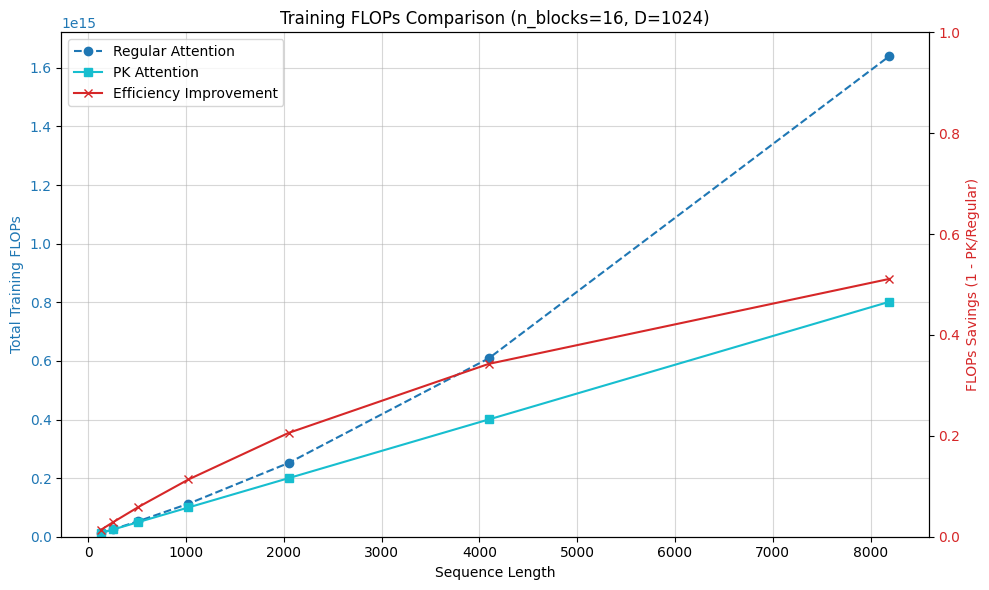

In [39]:
def plot_flops_comparison(
    n_blocks: int,
    batch_size: int,
    vocab_size: int,
    top_k: int,
    seq_lens: list,
    model_dim: int = None,
):
    if model_dim is None:
        model_dim = 64 * n_blocks

    pk_total_flops = []
    regular_total_flops = []
    ratios = []

    for s in seq_lens:
        pk_res = calculate_training_flops(
            n_blocks=n_blocks,
            model_dim=model_dim,
            batch_size=batch_size,
            seq_len=s,
            vocab_size=vocab_size,
            attention_type="pk",
            top_k=top_k,
        )
        reg_res = calculate_training_flops(
            n_blocks=n_blocks,
            model_dim=model_dim,
            batch_size=batch_size,
            seq_len=s,
            vocab_size=vocab_size,
            attention_type="regular",
            top_k=top_k,
        )

        pk_total_flops.append(pk_res[0])
        regular_total_flops.append(reg_res[0])
        ratios.append(1 - (pk_res[0] / reg_res[0]))

    fig, ax1 = plt.subplots(figsize=(10, 6))

    ax1.set_xlabel("Sequence Length")
    ax1.set_ylabel("Total Training FLOPs", color="tab:blue")
    ax1.plot(
        seq_lens,
        regular_total_flops,
        label="Regular Attention",
        marker="o",
        color="tab:blue",
        linestyle="--",
    )
    ax1.plot(
        seq_lens, pk_total_flops, label="PK Attention", marker="s", color="tab:cyan"
    )
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax1.grid(True, which="both", ls="-", alpha=0.5)
    ax1.set_ylim(bottom=0)

    ax2 = ax1.twinx()
    ax2.set_ylabel("FLOPs Savings (1 - PK/Regular)", color="tab:red")
    ax2.plot(
        seq_lens, ratios, label="Efficiency Improvement", marker="x", color="tab:red"
    )
    ax2.tick_params(axis="y", labelcolor="tab:red")
    ax2.set_ylim(0, 1.0)

    # --- Combined Legend Code ---
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
    # ----------------------------

    plt.title(f"Training FLOPs Comparison (n_blocks={n_blocks}, D={model_dim})")
    fig.tight_layout()
    plt.show()

n_blocks = 16
batch_size = 64
vocab_size = 50304
top_k = 16
seq_lens = [128, 256, 512, 1024, 2048, 4096, 8192]

plot_flops_comparison(
    n_blocks=n_blocks,
    batch_size=batch_size,
    vocab_size=vocab_size,
    top_k=top_k,
    seq_lens=seq_lens,
)

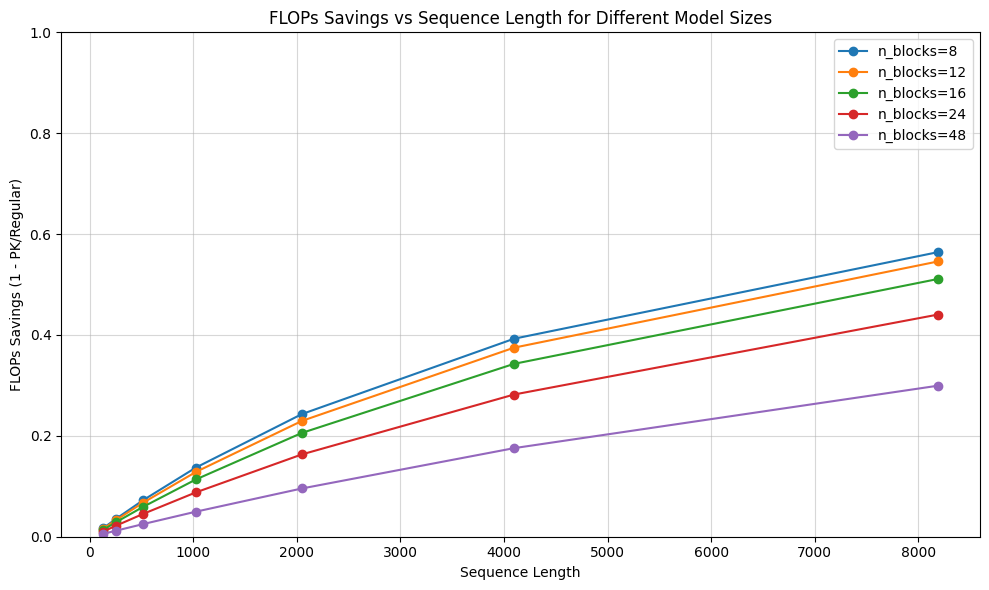

In [40]:
plot_savings_by_model_size(
    n_blocks_list=[8, 12, 16, 24, 48],
    batch_size=64,
    vocab_size=50304,
    top_k=16,
    seq_lens=[128, 256, 512, 1024, 2048, 4096, 8192],
)

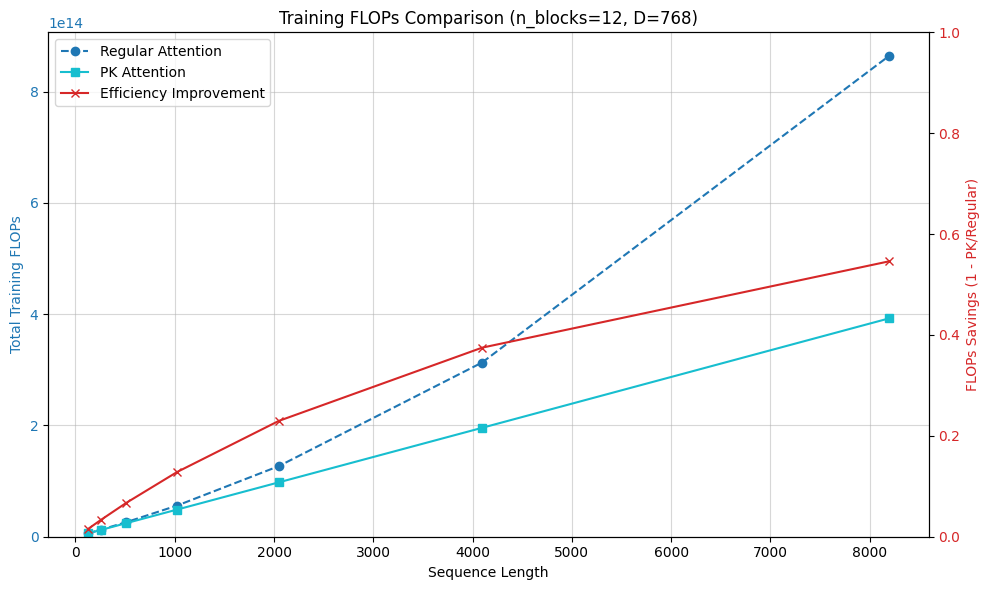

In [41]:
plot_flops_comparison(
    n_blocks=12,
    batch_size=64,
    vocab_size=50304,
    top_k=16,
    seq_lens=[128, 256, 512, 1024, 2048, 4096, 8192],
)

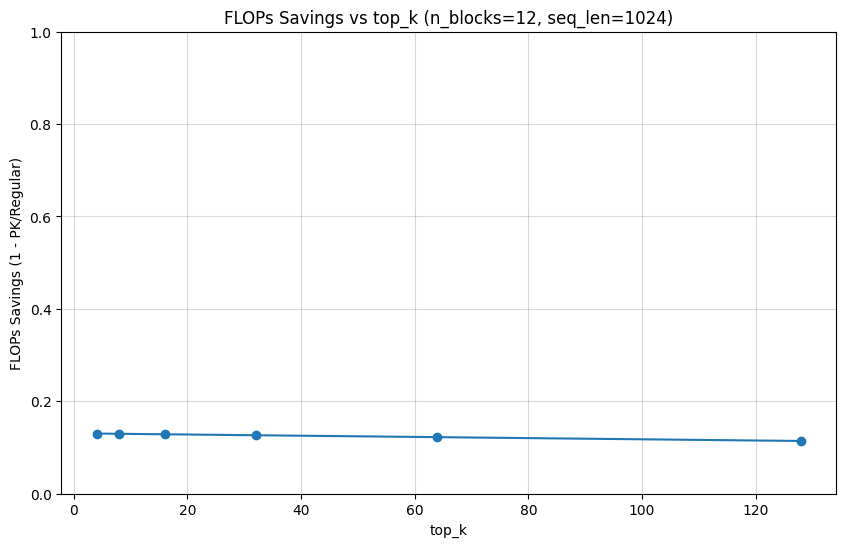

In [42]:
plot_savings_by_top_k(
    n_blocks=12,
    seq_len=1024,
    batch_size=64,
    vocab_size=50304,
    top_k_list=[4, 8, 16, 32, 64, 128],
)

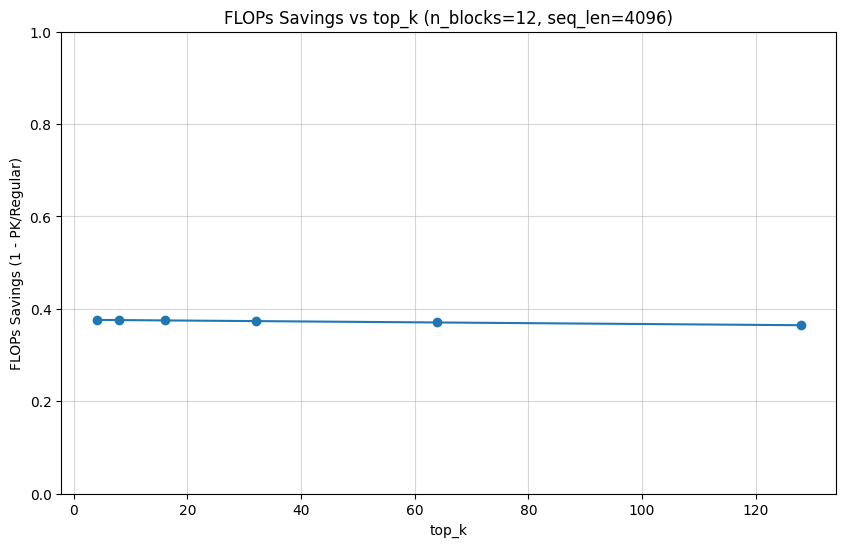

In [43]:
plot_savings_by_top_k(
    n_blocks=12,
    seq_len=4096,
    batch_size=64,
    vocab_size=50304,
    top_k_list=[4, 8, 16, 32, 64, 128],
)

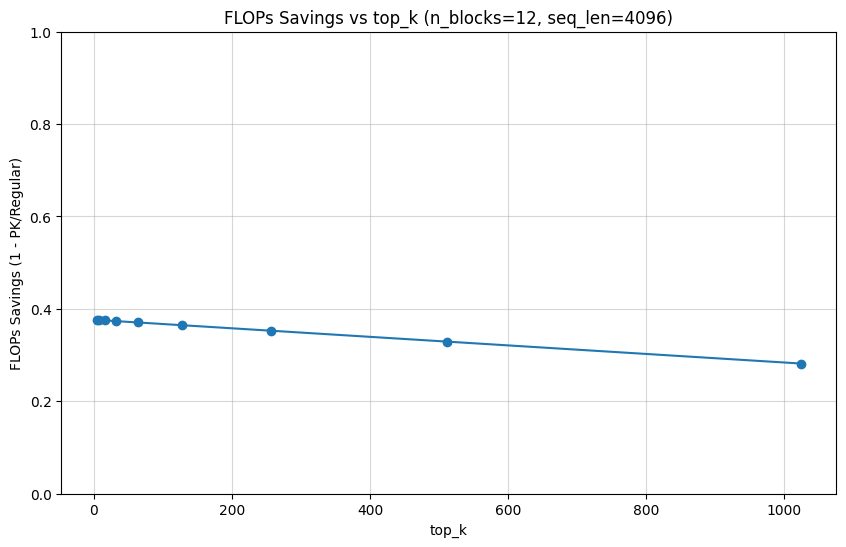

In [44]:
plot_savings_by_top_k(
    n_blocks=12,
    seq_len=4096,
    batch_size=64,
    vocab_size=50304,
    top_k_list=[4, 8, 16, 32, 64, 128, 256, 512, 1024],
)

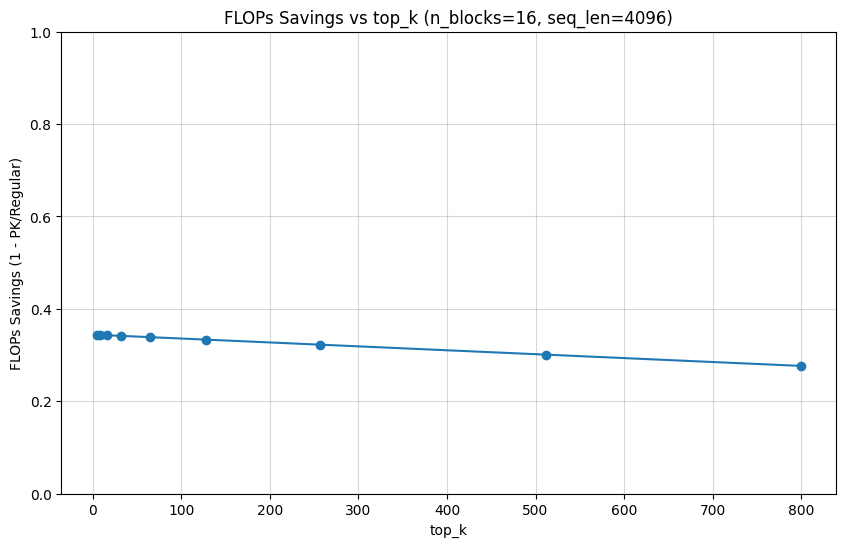

In [45]:
plot_savings_by_top_k(
    n_blocks=16,
    seq_len=4096,
    batch_size=64,
    vocab_size=50304,
    top_k_list=[4, 8, 16, 32, 64, 128, 256, 512, 800],
)

In [46]:
n_blocks = 12
batch_size = 64
seq_len = 1024
vocab_size = 50304
n_steps = 40001

pk_steps = calculate_steps_for_equal_flops(
    n_blocks=n_blocks,
    batch_size=batch_size,
    seq_len=seq_len,
    vocab_size=vocab_size,
    n_steps=n_steps,
)

print(f"For {n_steps} steps of regular attention, PK attention should be trained for {pk_steps:.0f} steps to match FLOPs.")

For 40001 steps of regular attention, PK attention should be trained for 45892 steps to match FLOPs.


In [47]:
n_blocks = 16
batch_size = 64
seq_len = 1024
vocab_size = 50304
n_steps = 80001

pk_steps = calculate_steps_for_equal_flops(
    n_blocks=n_blocks,
    batch_size=batch_size,
    seq_len=seq_len,
    vocab_size=vocab_size,
    n_steps=n_steps,
)

print(f"For {n_steps} steps of regular attention, PK attention should be trained for {pk_steps:.0f} steps to match FLOPs.")

For 80001 steps of regular attention, PK attention should be trained for 90244 steps to match FLOPs.


In [49]:
n_blocks = 12
batch_size = 64
seq_len = 4096
vocab_size = 50304
n_steps = 10001

for top_k in [16, 32, 64]:
    pk_steps = calculate_steps_for_equal_flops(
        n_blocks=n_blocks,
        batch_size=batch_size,
        seq_len=seq_len,
        vocab_size=vocab_size,
        n_steps=n_steps,
        top_k=top_k
    )

    print(f"For {n_steps} steps of regular attention, PK attention should be trained for {pk_steps:.0f} steps to match FLOPs.")

For 10001 steps of regular attention, PK attention should be trained for 15997 steps to match FLOPs.
For 10001 steps of regular attention, PK attention should be trained for 15959 steps to match FLOPs.
For 10001 steps of regular attention, PK attention should be trained for 15884 steps to match FLOPs.
